In [8]:
%load_ext autoreload
%autoreload 2

from subareas import Subareas
from subarea_calculations import SubareaCalculations
from sng_bond_simulation import SingleCountryBondSimulation
from mlt_bond_simulation import MultiCountryBondSimulation
from premium_class import PremiumCalculations
import pooling_functions as pf

from climada.hazard import TCTracks, Centroids, TropCyclone
from climada.entity import LitPop
from climada.entity import ImpfSetTropCyclone
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Set CAT Bond Basics

In [9]:
### Bond Basics ###
countries = [659, 388, 84]  # St. Kitts and Nevis, Jamaica, Belize
exhaustion_point = 0.5 # principal should be 50% of exposure 
attachment_point = 0.05 # minimum payout should be 5% of exposure
exhaustion_point_method = 'Exposure_Share' # could also be "Return_Period" or None
attachment_point_method = 'Exposure_Share' # could also be "Return_Period" or None
term = 3  # term of bond in years
num_of_terms = 20 # number of terms to simulate
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
resolution_st_kitts = 0.05 # resolution used to derive subareas for St. Kitts and Nevis
resolution_jamaica = 0.5 # resolution used to derive subareas for Jamaica
resolution_belize = 0.5 # resolution used to derive subareas for Belize

### Pricing Basics ###
peak_peril = 0 # indicator if bond is considered peak peril (1) or not (0)
hybrid_trigger = 0 # indicator if bond contains a hybrid trigger (1) or not (0)
investment_graded = 0 # indicator if bond is investment graded (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio for benchmark pricing 
risk_free_rate = 0.0  # risk free rate for Sharpe ratio and simulation of returns

### Define Exposure, Hazard, and Vulnerability

In [10]:
### ST. KITTS AND NEVIS ###
tr_irma = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2017242N16333"
)  # IRMA 2017
tr_irma.equal_timestep()
tr_irma.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.0, 17.5, -62.9, -62.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_irma = TropCyclone.from_tracks(tr_irma, centroids=cent)


exp_kit = LitPop.from_countries(
        [str(countries[0])], fin_mode='gdp', reference_year=2020
    )

impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_kit.gdf.loc[exp_kit.gdf.region_id == countries[0], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_irma.date = np.array([736576, 736596, 736649, 736659, 736668, 736681, 736701, 736702, 736715, 736726,
 736727, 736731, 736743, 736753, 736762, 736781, 736787, 736803, 736808, 736821,
 736843, 736848, 736854, 736868, 736872, 736878, 736892, 736900, 736904, 736912,
 736921, 736926, 736940, 736945, 736952, 736963, 736976, 736983, 736993, 737003,
 737012, 737020, 737031, 737037, 737048, 737059, 737068, 737074, 737081, 737092,
 737098])

2025-11-28 10:04:14,222 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-28 10:04:14,317 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-28 10:04:14,417 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-28 10:04:17,972 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-28 10:04:18,027 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 546 coastal centroids.
2025-11-28 10:04:18,393 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-28 10:04:18,693 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-28 10:04:19,011 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-28 10:04:19,347 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-28 10:04:19,673 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-28

In [11]:
tr_melissa = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2025291N11319"
)  # Melissa 2025
tr_melissa.equal_timestep()
tr_melissa.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.5, 18.75, -78.5, -76
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_melissa = TropCyclone.from_tracks(tr_melissa, centroids=cent)


exp_jam = LitPop.from_countries(
        [str(countries[1])], fin_mode='gdp', reference_year=2020
    )

iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_jam.gdf.loc[exp_jam.gdf.region_id == countries[1], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_melissa.date = np.array([736694, 736774, 736874, 736981, 737013, 737080, 737099, 737155,
       737206, 737297, 737398, 737401, 737482, 737496, 737535, 737576,
       737630, 737677, 737681, 737732, 737765, 737825, 737887, 737937,
       737990, 738024, 738086, 738175, 738278, 738297, 738334, 738390,
       738452, 738536, 738563, 738582, 738633, 738701, 738738, 738795,
       738850, 738884, 738928, 738989, 739062, 739101, 739143, 739193,
       739221, 739268, 739297])

2025-11-28 10:04:30,360 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-28 10:04:30,441 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-28 10:04:30,483 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-28 10:04:34,100 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-28 10:04:34,207 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 7938 coastal centroids.
2025-11-28 10:04:39,812 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-28 10:04:44,285 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-28 10:04:49,208 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-28 10:04:54,024 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-28 10:04:58,485 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-2

In [12]:
tr_keith = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2000273N16277"
)  # Melissa 2025
tr_keith.equal_timestep()
tr_keith.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 15.5, 18.75, -89.5, -87.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_keith = TropCyclone.from_tracks(tr_keith, centroids=cent)


exp_bel = LitPop.from_countries(
        [countries[2]], fin_mode='gdp', reference_year=2020
    )

iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_bel.gdf.loc[exp_bel.gdf.region_id == countries[2], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_keith.date = np.array([736694, 736774, 736874, 736981, 737013, 737080, 737099, 737155,
       737206, 737297, 737398, 737401, 737482, 737496, 737535, 737576,
       737630, 737677, 737681, 737732, 737765, 737825, 737887, 737937,
       737990, 738024, 738086, 738175, 738278, 738297, 738334, 738390,
       738452, 738536, 738563, 738582, 738633, 738701, 738738, 738795,
       738850, 738884, 738928, 738989, 739062, 739101, 739143, 739193,
       739221, 739268, 739297])

2025-11-28 10:05:19,071 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-28 10:05:19,146 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-28 10:05:19,190 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-28 10:05:21,702 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-28 10:05:21,764 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 16463 coastal centroids.
2025-11-28 10:05:29,444 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-28 10:05:37,352 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-28 10:05:45,007 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-28 10:05:52,790 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-28 10:06:00,515 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-

### Initialise Subarea Class

2025-11-28 10:06:38,729 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


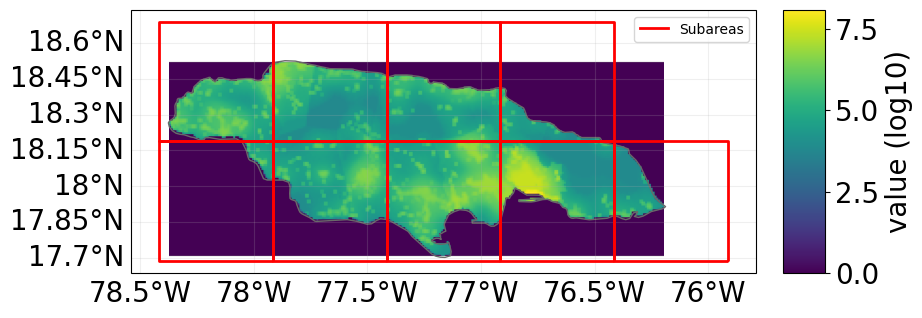

2025-11-28 10:06:56,861 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


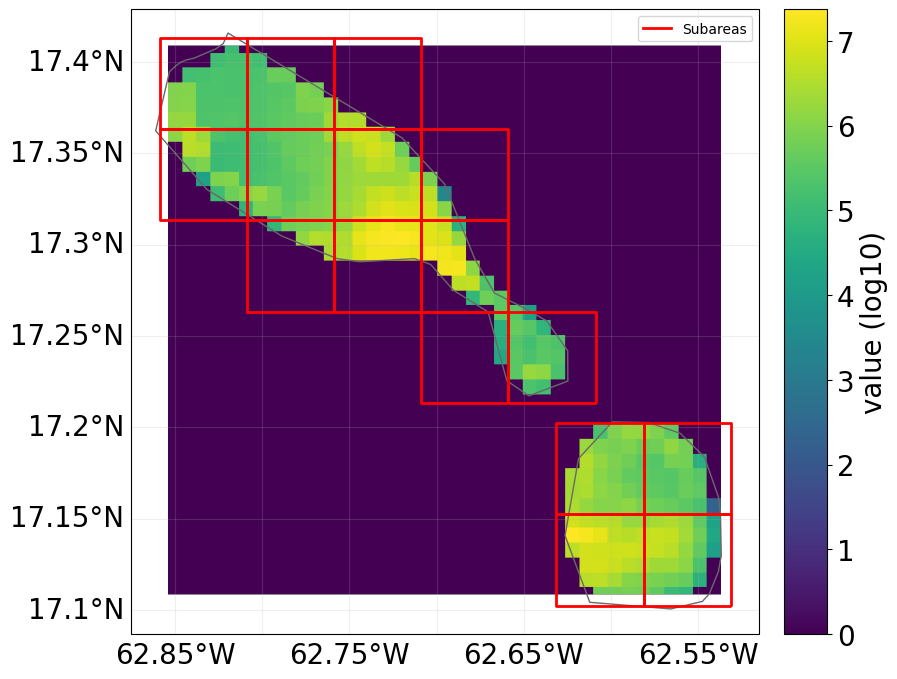

2025-11-28 10:07:11,311 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


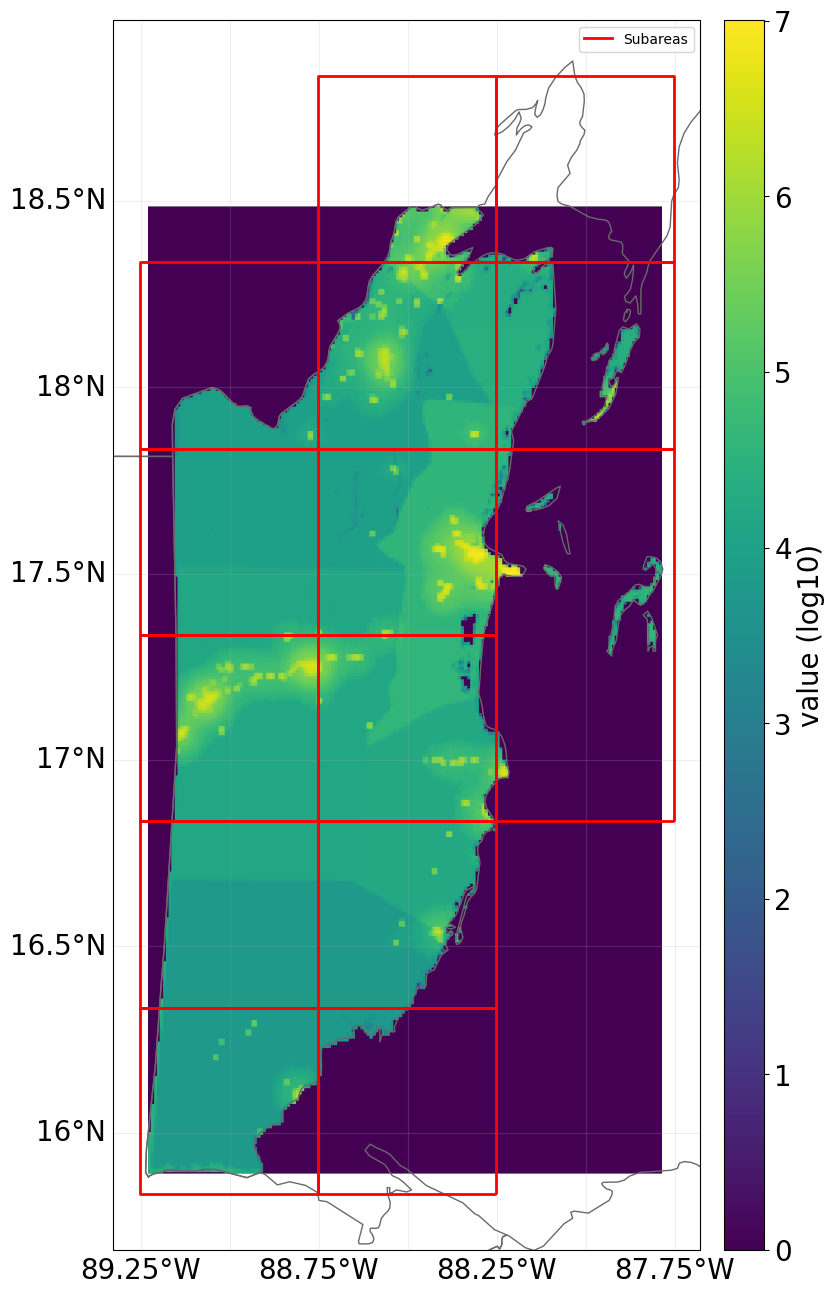

In [13]:
st_kitts_subareas = Subareas.from_resolution(tc_irma, impfset, exp_kit, resolution=resolution_st_kitts)
jamaica_subareas = Subareas.from_resolution(tc_melissa, impfset, exp_jam, resolution=resolution_jamaica)
belize_subareas = Subareas.from_resolution(tc_keith, impfset, exp_bel, resolution=resolution_belize)
jamaica_subareas.plot()
st_kitts_subareas.plot()
belize_subareas.plot()

### Subarea Calculations

In [14]:
st_kitts_sub_calc = SubareaCalculations(subareas=st_kitts_subareas, index_stat=par_index)
jamaica_sub_calc = SubareaCalculations(subareas=jamaica_subareas, index_stat=par_index)
belize_sub_calc = SubareaCalculations(subareas=belize_subareas, index_stat=par_index)
st_kitts_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)
jamaica_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)
belize_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)

2025-11-28 10:07:31,712 - climada.entity.exposures.base - INFO - Matching 328 exposures with 546 centroids.
2025-11-28 10:07:31,722 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2025-11-28 10:07:31,729 - climada.engine.impact_calc - INFO - Calculating impact for 984 assets (>0) and 51 events.
2025-11-28 10:07:32,673 - climada.entity.exposures.base - INFO - Matching 13552 exposures with 7938 centroids.
2025-11-28 10:07:32,682 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2025-11-28 10:07:32,711 - climada.engine.impact_calc - INFO - Calculating impact for 40503 assets (>0) and 51 events.
2025-11-28 10:07:33,569 - climada.entity.exposures.base - INFO - Matching 27265 exposures with 16463 centroids.
2025-11-28 10:07:33,585 - climada.util.coordinates - INFO - No exact centroid match found. Reprojec

### Single-Country Bond Simulation

In [15]:
### ST. KITTS AND NEVIS BOND SIMULATION ###
st_kitts_bond_sim = SingleCountryBondSimulation(subarea_calc=st_kitts_sub_calc, term=term, number_of_terms=num_of_terms) 
st_kitts_bond_sim.init_loss_simulation()
st_kitts_premiums = PremiumCalculations(bond_simulation_class=st_kitts_bond_sim)
st_kitts_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
st_kitts_premiums.calc_ibrd_premium()
st_kitts_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
st_kitts_bond_sim.init_return_simulation(premium=st_kitts_premiums.chatoro_prem_rate)
display(st_kitts_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(st_kitts_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(st_kitts_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(st_kitts_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.017543859649122806,
 'AP_ann': 0.023391812865497075,
 'Tot_payout': 1325883333.3333325,
 'Tot_damages': 11037139919.100546,
 'VaR_95_ann': 0.0,
 'ES_95_ann': 0.75,
 'VaR_99_ann': 0.7555314181864904,
 'ES_99_ann': 1.0}

Benchmark Sharpe Ratio premium rate: 8.7
Chatoro premium rate: 8.5
IBRD premium rate: 5.0


In [16]:
### JAMAICA BOND SIMULATION ###
jamaica_bond_sim = SingleCountryBondSimulation(subarea_calc=jamaica_sub_calc, term=term, number_of_terms=num_of_terms) 
jamaica_bond_sim.init_loss_simulation()
jamaica_premiums = PremiumCalculations(bond_simulation_class=jamaica_bond_sim)
jamaica_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
jamaica_premiums.calc_ibrd_premium()
jamaica_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
jamaica_bond_sim.init_return_simulation(premium=jamaica_premiums.chatoro_prem_rate)
display(jamaica_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(jamaica_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(jamaica_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(jamaica_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.02680332628076214,
 'AP_ann': 0.08771929824561403,
 'Tot_payout': 31653711605.811665,
 'Tot_damages': 50919862874.32074,
 'VaR_95_ann': 0.12926162262991353,
 'ES_95_ann': 0.4462644805505158,
 'VaR_99_ann': 0.8387774672602343,
 'ES_99_ann': 0.8543436945180888}

Benchmark Sharpe Ratio premium rate: 9.8
Chatoro premium rate: 9.8
IBRD premium rate: 6.0


In [17]:
belize_bond_sim = SingleCountryBondSimulation(subarea_calc=belize_sub_calc, term=term, number_of_terms=num_of_terms) 
belize_bond_sim.init_loss_simulation()
belize_premiums = PremiumCalculations(bond_simulation_class=belize_bond_sim)
belize_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
belize_premiums.calc_ibrd_premium()
belize_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
belize_bond_sim.init_return_simulation(premium=belize_premiums.chatoro_prem_rate)
display(belize_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(belize_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(belize_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(belize_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.03539315772390796,
 'AP_ann': 0.11695906432748537,
 'Tot_payout': 6181898997.912401,
 'Tot_damages': 9590299020.561695,
 'VaR_95_ann': 0.2502831832790935,
 'ES_95_ann': 0.42061594416208714,
 'VaR_99_ann': 0.5701643301269493,
 'ES_99_ann': 0.6061999788723924}

Benchmark Sharpe Ratio premium rate: 10.1
Chatoro premium rate: 11.0
IBRD premium rate: 6.9


### Multi-Country Bond Simulation

In [18]:
#create dictionary of country bond simulation classes
sng_bonds_dic = {countries[0]: st_kitts_bond_sim,
                 countries[1]: jamaica_bond_sim,
                 countries[2]: belize_bond_sim}

In [19]:
mlt_cat_bond = MultiCountryBondSimulation(country_dictionary=sng_bonds_dic, term=term,number_of_terms=num_of_terms)
mlt_cat_bond.init_required_principal()
mlt_cat_bond.init_loss_simulation(principal=mlt_cat_bond.requ_principal, confidence_levels=[0.95,0.99])
mlt_bond_premiums = PremiumCalculations(bond_simulation_class=mlt_cat_bond)
mlt_bond_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
mlt_bond_premiums.calc_ibrd_premium()
mlt_bond_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
mlt_cat_bond.init_return_simulation_tranches(premiums=[mlt_bond_premiums.chatoro_prem_rate,mlt_bond_premiums.chatoro_prem_rate], tranches=[0.2,0.8])
mlt_cat_bond.init_return_simulation(premium=mlt_bond_premiums.chatoro_prem_rate)
display(mlt_cat_bond.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(mlt_bond_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(mlt_bond_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(mlt_bond_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.029481977291732603,
 'AP_ann': 0.14035087719298245,
 'Payout': 39161493937.057396,
 'Damage': 71547301813.98299,
 'VaR_95_ann': 0.15776731924400075,
 'ES_95_ann': 0.43875569600979597,
 'VaR_99_ann': 0.7602314866443391,
 'ES_99_ann': 0.807913900425695}

Benchmark Sharpe Ratio premium rate: 9.8
Chatoro premium rate: 10.2
IBRD premium rate: 6.3


In [ ]:
pool_n_dic, pool_allocation_n_pool, algorithm_result_n_pool = MultiCountryBondSimulation.simulate_bond_pool_n(country_dictionary=sng_bonds_dic, 
                                                                                                              term=term, 
                                                                                                              number_of_terms=num_of_terms, 
                                                                                                              principal=mlt_cat_bond.requ_principal, 
                                                                                                              number_pools=2, 
                                                                                                              n_opt_rep=2)
print(pool_n_dic[1].countries)
display(pool_n_dic[1].loss_metrics)
print(pool_n_dic[2].countries)
display(pool_n_dic[2].loss_metrics)

659
{2: [659]}
388
{2: [659, 388]}
84
{2: [659, 388], 1: [84]}
2 [659, 388]
1 [84]


In [ ]:
pool_max_prinipal_dic, pool_allocation_max_prin, algorithm_result_max_prin = MultiCountryBondSimulation.simulate_bond_max_principal_pool(country_dictionary=sng_bonds_dic, 
                                                                                                                                         term=term, 
                                                                                                                                         number_of_terms=num_of_terms, 
                                                                                                                                         principal=mlt_cat_bond.requ_principal, 
                                                                                                                                         maximum_principal=1000000000, 
                                                                                                                                         n_opt_rep=2)
print(pool_max_prinipal_dic[1].countries)
display(pool_max_prinipal_dic[1].loss_metrics)
print(pool_max_prinipal_dic[2].countries)
display(pool_max_prinipal_dic[2].loss_metrics)

2 [659, 388]
1 [84]
[84]


{'EL_ann': 0.0046539237284759375,
 'AP_ann': 0.11695906432748537,
 'Payout': 6181898997.912401,
 'Damage': 9590299020.561695,
 'VaR_95_ann': 0.03291028324139181,
 'ES_95_ann': 0.05530771055753955,
 'VaR_99_ann': 0.07497215495174554,
 'ES_99_ann': 0.07971056123003463}

[659, 388]


{'EL_ann': 0.02482805356325667,
 'AP_ann': 0.0935672514619883,
 'Payout': 32979594939.144997,
 'Damage': 61957002793.421295,
 'VaR_95_ann': 0.1214322895521304,
 'ES_95_ann': 0.44214232744004733,
 'VaR_99_ann': 0.7457273298119343,
 'ES_99_ann': 0.7595667109843475}